In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [19]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"

df = pd.read_csv(
    url,
    sep=";",
    compression="zip",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (2075259, 9)

Column names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [5]:
print(df.isnull().sum())
df = df.replace('?', pd.NA)

numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values after conversion:")
print(df.isnull().sum())

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64
Missing values after conversion:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:

df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek

# Display the result
df[['datetime', 'hour', 'day', 'month', 'day_of_week',
    'Global_active_power']].head()

,datetime,hour,day,month,day_of_week,Global_active_power
0,2006-12-16 17:24:00,17,16,12,5,4.216
1,2006-12-16 17:25:00,17,16,12,5,5.360
2,2006-12-16 17:26:00,17,16,12,5,5.374
3,2006-12-16 17:27:00,17,16,12,5,5.388
4,2006-12-16 17:28:00,17,16,12,5,3.666


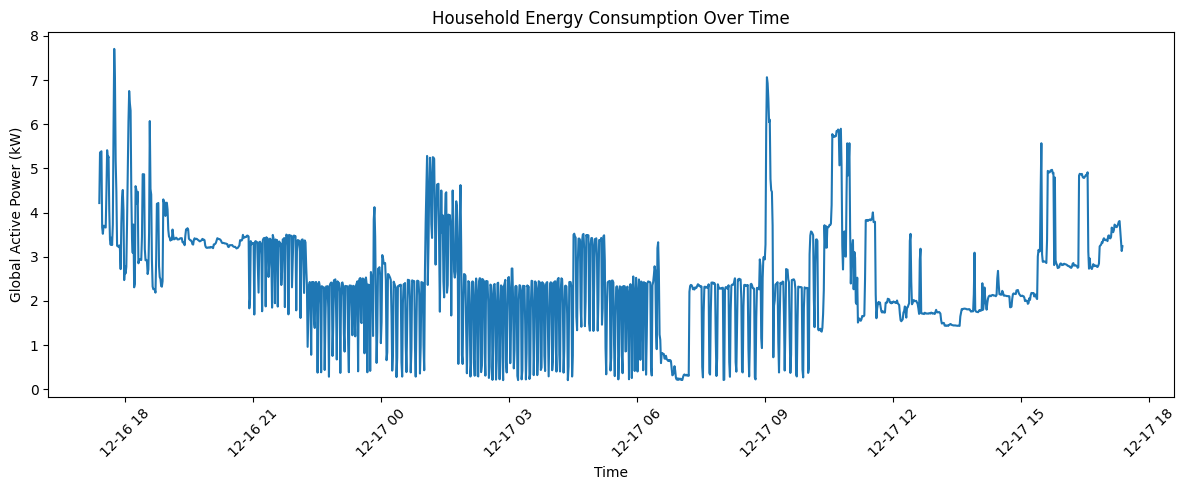

In [7]:
# Plot power consumption over the first 24 hours

sample = df.iloc[:1440]

plt.figure(figsize=(12, 5))
plt.plot(sample['datetime'], sample['Global_active_power'])

plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.title("Household Energy Consumption Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
features = [
    'hour',
    'day',
    'month',
    'day_of_week',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity'
]

X = df[features]
y = df['Global_active_power']

valid_data = pd.concat([X, y], axis=1).dropna()

X = valid_data[features]
y = valid_data['Global_active_power']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2049280, 7)
Target shape: (2049280,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1639424
Testing samples: 409856


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[1.52256379 0.40905987 0.66423412 0.27757018 1.34823505 0.34429473
 0.20109909 2.20320126 0.4991654  1.78088872]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.028618409208457367
Root Mean Squared Error: 0.04322071761257793
R² Score: 0.9983379676460501


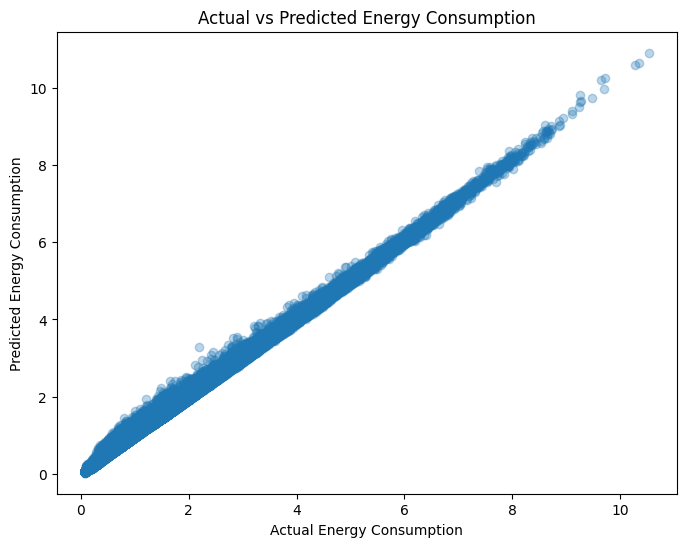

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")

plt.show()